# Yolo12

### Overview

YOLO12 introduces an attention-centric architecture that departs from the traditional CNN-based approaches used in previous YOLO models, yet retains the real-time inference speed essential for many applications. This model achieves state-of-the-art object detection accuracy through novel methodological innovations in attention mechanisms and overall network architecture, while maintaining real-time performance. Despite those advantages, YOLO12 remains a community-driven release that may exhibit training instability, elevated memory consumption, and slower CPU throughput due to its heavy attention blocks, so Ultralytics still recommends YOLO11 for most production workloads.

----

Conda env : [cv_playgrounds](../README.md#setup-a-conda-environment)

----

- Ref: 
    - https://docs.ultralytics.com/models/yolo12/#detection-performance-coco-val2017

### Key Improvements

1. Enhanced Feature Extraction:

- **Area Attention**: Efficiently handles large receptive fields, reducing computational cost.
- **Optimized Balance**: Improved balance between attention and feed-forward network computations.
- **R-ELAN**: Enhances feature aggregation using the R-ELAN architecture.

2. Optimization Innovations:

- **Residual Connections**: Introduces residual connections with scaling to stabilize training, especially in larger models.
- **Refined Feature Integration**: Implements an improved method for feature integration within R-ELAN.
- **FlashAttention**: Incorporates FlashAttention to reduce memory access overhead.


3. Architectural Efficiency:

- **Reduced Parameters**: Achieves a lower parameter count while maintaining or improving accuracy compared to many previous models.
- **Streamlined Attention**: Uses a simplified attention implementation, avoiding positional encoding.
- **Optimized MLP Ratios**: Adjusts MLP ratios to more effectively allocate computational resources.

In [1]:
!nvidia-smi

Sat Nov 29 16:15:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     On  |   00000000:01:00.0  On |                  N/A |
| 22%   40C    P8             28W /  250W |     631MiB /  11264MiB |     30%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Download Test Data

In [1]:
from ultralytics.utils.downloads import safe_download
images = ["bus.jpg", "zidane.jpg"]
for img in images:
  path = safe_download(f"https://ultralytics.com/assets/{img}", dir="temp_assets")


image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x480 4 persons, 1 bus, 20.0ms
Speed: 2.2ms preprocess, 20.0ms inference, 6.1ms postprocess per image at shape (1, 3, 640, 480)


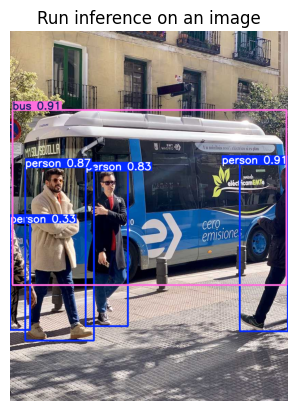

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("./temp_model/yolo12n.pt")

results = model("./temp_assets/bus.jpg")

# # Show results
# results[0].show()
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()


image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 384x640 2 persons, 1 tie, 48.2ms
Speed: 2.1ms preprocess, 48.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


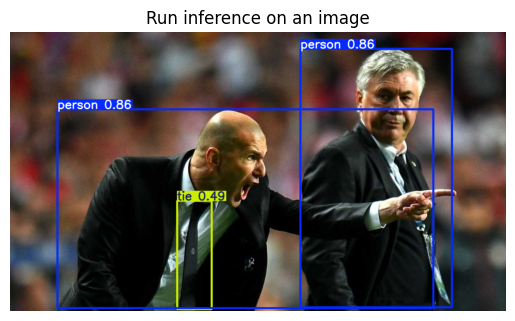

In [ ]:

results = model("./temp_assets/zidane.jpg")

# # Show results
# results[0].show()
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()